In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from miss_alignment.data.shift_generation import JitterGenerator, OutlierGenerator, TrajectoryGenerator

sns.set(context='paper', style='whitegrid')

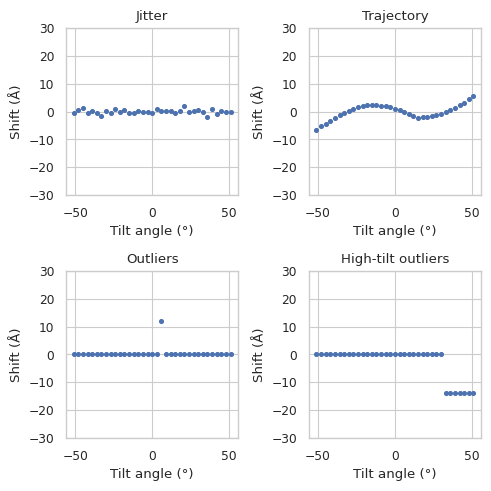

In [53]:
n_tilts = 35
tilt_angles = np.linspace(-51, 51, n_tilts)

shift_dict = {
    'Jitter': JitterGenerator(jitter_max_std=2.0),
    'Trajectory': TrajectoryGenerator(trajectory_max_shift=10.0),
    'Outliers': OutlierGenerator(outlier_max_shift=20, max_sequence_length=3),
    'High-tilt outliers': OutlierGenerator(outlier_max_shift=30, max_sequence_length=7, edge_only=True), 
}

fig, ax = plt.subplots(2, 2, figsize=(5,5))
for i, (label, shift) in enumerate(shift_dict.items()):
    subplot = ax[i // 2][i % 2]
    subplot.scatter(tilt_angles, shift(n_tilts)[:, 0], s=8)
    subplot.set_ylim(-30, 30)
    subplot.set_ylabel('Shift (Å)')
    subplot.set_xlabel('Tilt angle (°)')
    subplot.set_title(label)

fig.tight_layout()
plt.savefig('shift_illustration.png', dpi=300, bbox_inches='tight')